<a href="https://colab.research.google.com/github/alaae2007/CST184/blob/main/Week_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[1] "Original Climate Matrix:"
  CO2 Temp Deforestation Renewables
A 9.2  1.1           0.8         15
B 6.5  0.9           1.2         30
C 2.3  0.7           2.5         60
D 3.8  1.0           1.5         45
E 7.1  1.2           0.9         25
F 4.2  1.0           2.1         50
[1] "Scaled Climate Matrix:"
    CO2  Temp Deforestation Renewables
A  1.45  0.68         -1.03      -1.33
B  0.39 -0.48         -0.44      -0.44
C -1.27 -1.64          1.47       1.33
D -0.68  0.10          0.00       0.44
E  0.63  1.26         -0.88      -0.74
F -0.52  0.10          0.88       0.74
attr(,"scaled:center")
          CO2          Temp Deforestation    Renewables 
    5.5166667     0.9833333     1.5000000    37.5000000 
attr(,"scaled:scale")
          CO2          Temp Deforestation    Renewables 
    2.5325218     0.1722401     0.6782330    16.9558250 
[1] "Means after scaling:"
          CO2          Temp Deforestation    Renewables 
            0             0             0             0 
[

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’




[1] "Melted Correlation Matrix:"
           Var1 Var2      value
1           CO2  CO2  1.0000000
2          Temp  CO2  0.7114442
3 Deforestation  CO2 -0.9117162
4    Renewables  CO2 -0.9862370
5           CO2 Temp  0.7114442
6          Temp Temp  1.0000000
[1] "Updated Climate Matrix:"
  CO2 Temp Deforestation Renewables
A 9.2  1.1           0.8         15
B 6.5  0.9           1.2         30
C 2.3  0.7           2.5         90
D 3.8  1.0           1.5         45
E 7.1  1.2           0.9         25
F 4.2  1.0           2.1         50
[1] "Updated Scaled Climate Matrix:"
    CO2  Temp Deforestation Renewables
A  1.45  0.68         -1.03      -1.03
B  0.39 -0.48         -0.44      -0.47
C -1.27 -1.64          1.47       1.79
D -0.68  0.10          0.00       0.09
E  0.63  1.26         -0.88      -0.66
F -0.52  0.10          0.88       0.28
attr(,"scaled:center")
          CO2          Temp Deforestation    Renewables 
    5.5166667     0.9833333     1.5000000    42.5000000 
attr(,"scaled:

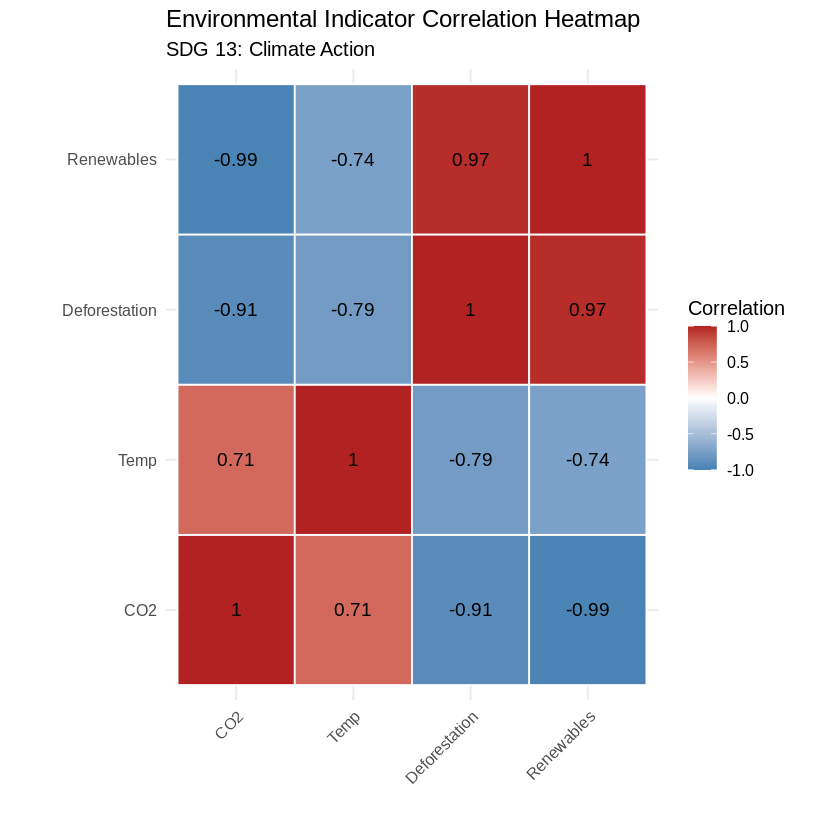

[1] "Renewable Correlation Comparison:"
      Indicator Original Updated
1           CO2    -0.99   -0.92
2          Temp    -0.74   -0.84
3 Deforestation     0.97    0.95

How did changing Country C affect the correlations?

Increasing Country C's renewable energy share from 60% to 90%
changes the correlations between renewable energy and the other
environmental indicators.

The relationship between renewables and CO2 emissions remains
negative, meaning countries with higher renewable energy shares in
this small dataset generally tend to have lower CO2 emissions.

The correlations with temperature anomaly and deforestation also
change because Country C now has a substantially different renewable
energy value.

This demonstrates that correlation results depend on the observations
contained in the dataset. Because there are only six countries in
this example, changing one value can noticeably affect the results.

Reflection:

This analysis demonstrates how matrices can be used to repres

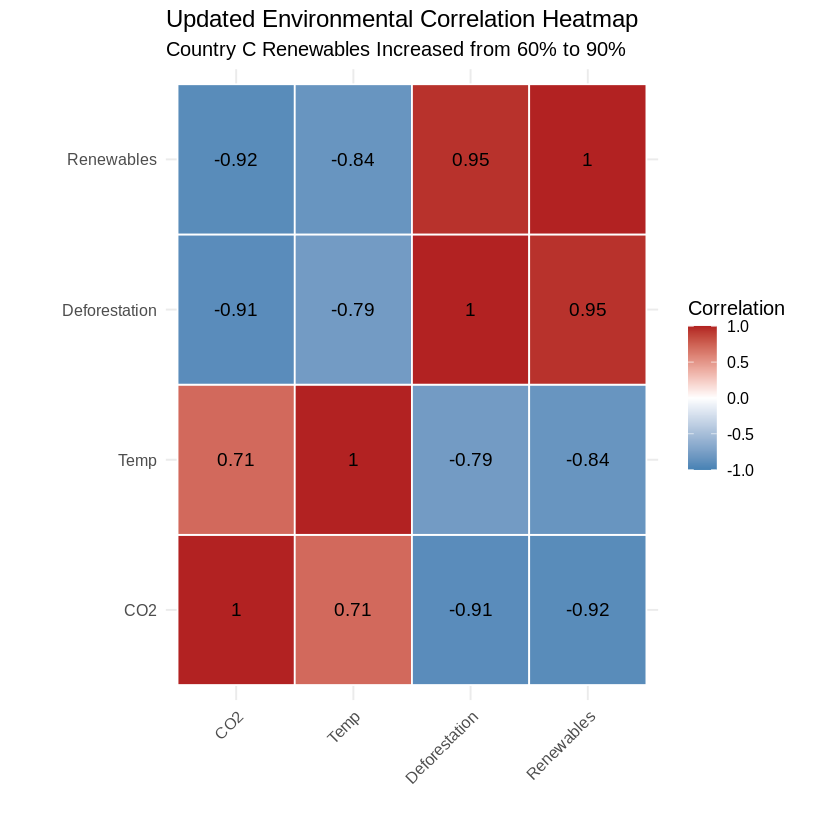

In [ ]:
# CST184 Week 8
# R, Matrices, Vectors and Data Transformation
# SDG Climate Correlation Heatmap

# Step 1: Create the climate indicator matrix

climate <- matrix(c(
  9.2, 1.1, 0.8, 15,
  6.5, 0.9, 1.2, 30,
  2.3, 0.7, 2.5, 60,
  3.8, 1.0, 1.5, 45,
  7.1, 1.2, 0.9, 25,
  4.2, 1.0, 2.1, 50
), nrow = 6, byrow = TRUE)

colnames(climate) <- c(
  "CO2",
  "Temp",
  "Deforestation",
  "Renewables"
)

rownames(climate) <- c(
  "A",
  "B",
  "C",
  "D",
  "E",
  "F"
)

print("Original Climate Matrix:")
print(climate)


# Step 2: Standardize the data

scaled_climate <- scale(climate)

print("Scaled Climate Matrix:")
print(round(scaled_climate, 2))


# Check the means after scaling

print("Means after scaling:")
print(round(colMeans(scaled_climate), 2))


# Check the standard deviations after scaling

print("Standard deviations after scaling:")
print(
  round(
    apply(scaled_climate, 2, sd),
    2
  )
)


# Scaling question

cat("
Why is scaling important?

Scaling puts variables measured on different scales onto a common
scale with a mean of 0 and standard deviation of 1.

For example, renewable energy percentages are much larger numerically
than temperature anomalies. Standardising makes the variables easier
to compare and prevents differences in measurement scale from
dominating some types of analysis.

Correlation itself is already scale-independent, so scaling does not
change the Pearson correlation values. However, standardisation is
still useful for demonstrating data transformation and is important
for many other statistical and machine-learning techniques.
")


# Step 3: Compute the correlation matrix

cor_matrix <- cor(scaled_climate)

print("Correlation Matrix:")
print(round(cor_matrix, 2))


# Identify some important correlations

cat("
Correlation Interpretation:

A correlation close to +1 represents a strong positive relationship.

A correlation close to -1 represents a strong negative relationship.

A correlation close to 0 represents a weak linear relationship.

The diagonal values are all 1 because each environmental indicator
has a perfect correlation with itself.
")


# Step 4: Prepare the correlation matrix for plotting

if (!requireNamespace("reshape2", quietly = TRUE)) {
  install.packages("reshape2")
}

library(reshape2)

melted <- melt(cor_matrix)

print("Melted Correlation Matrix:")
print(head(melted))


# Step 5: Create the heatmap

if (!requireNamespace("ggplot2", quietly = TRUE)) {
  install.packages("ggplot2")
}

library(ggplot2)

heatmap_original <- ggplot(
  melted,
  aes(
    x = Var1,
    y = Var2,
    fill = value
  )
) +
  geom_tile(
    color = "white",
    linewidth = 0.5
  ) +
  geom_text(
    aes(label = round(value, 2)),
    size = 4
  ) +
  scale_fill_gradient2(
    low = "steelblue",
    high = "firebrick",
    mid = "white",
    midpoint = 0,
    limit = c(-1, 1),
    name = "Correlation"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(
      angle = 45,
      hjust = 1
    )
  ) +
  labs(
    title = "Environmental Indicator Correlation Heatmap",
    subtitle = "SDG 13: Climate Action",
    x = "",
    y = ""
  )

print(heatmap_original)


# Save the original correlation values for comparison

original_cor_matrix <- cor_matrix


# Step 6: Modify Country C's renewable energy share

climate[3, 4] <- 90

print("Updated Climate Matrix:")
print(climate)


# Scale the modified data

scaled_climate <- scale(climate)

print("Updated Scaled Climate Matrix:")
print(round(scaled_climate, 2))


# Recalculate correlations

cor_matrix <- cor(scaled_climate)

print("Updated Correlation Matrix:")
print(round(cor_matrix, 2))


# Melt the updated matrix

melted <- melt(cor_matrix)


# Create the updated heatmap

heatmap_updated <- ggplot(
  melted,
  aes(
    x = Var1,
    y = Var2,
    fill = value
  )
) +
  geom_tile(
    color = "white",
    linewidth = 0.5
  ) +
  geom_text(
    aes(label = round(value, 2)),
    size = 4
  ) +
  scale_fill_gradient2(
    low = "steelblue",
    high = "firebrick",
    mid = "white",
    midpoint = 0,
    limit = c(-1, 1),
    name = "Correlation"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(
      angle = 45,
      hjust = 1
    )
  ) +
  labs(
    title = "Updated Environmental Correlation Heatmap",
    subtitle = "Country C Renewables Increased from 60% to 90%",
    x = "",
    y = ""
  )

print(heatmap_updated)


# Compare renewable correlations before and after

comparison <- data.frame(
  Indicator = c(
    "CO2",
    "Temp",
    "Deforestation"
  ),
  Original = c(
    original_cor_matrix["Renewables", "CO2"],
    original_cor_matrix["Renewables", "Temp"],
    original_cor_matrix["Renewables", "Deforestation"]
  ),
  Updated = c(
    cor_matrix["Renewables", "CO2"],
    cor_matrix["Renewables", "Temp"],
    cor_matrix["Renewables", "Deforestation"]
  )
)

comparison$Original <- round(
  comparison$Original,
  2
)

comparison$Updated <- round(
  comparison$Updated,
  2
)

print("Renewable Correlation Comparison:")
print(comparison)


# Step 6 Question

cat("
How did changing Country C affect the correlations?

Increasing Country C's renewable energy share from 60% to 90%
changes the correlations between renewable energy and the other
environmental indicators.

The relationship between renewables and CO2 emissions remains
negative, meaning countries with higher renewable energy shares in
this small dataset generally tend to have lower CO2 emissions.

The correlations with temperature anomaly and deforestation also
change because Country C now has a substantially different renewable
energy value.

This demonstrates that correlation results depend on the observations
contained in the dataset. Because there are only six countries in
this example, changing one value can noticeably affect the results.
")


# Reflection

cat("
Reflection:

This analysis demonstrates how matrices can be used to represent
multiple environmental indicators across countries.

Standardising the matrix transforms each variable to a common scale,
making the values easier to compare.

The correlation matrix identifies positive and negative relationships
between CO2 emissions, temperature anomalies, deforestation and
renewable energy use.

The heatmap makes these relationships easier to interpret visually.
Strong positive and negative correlations can be identified using the
colour scale and the correlation values displayed inside each cell.

After increasing Country C's renewable energy share, some of the
correlations change. This shows that correlation patterns are
sensitive to the underlying data, especially when working with a
small dataset.

These techniques could be applied to larger real-world climate
datasets to investigate environmental relationships and support
analysis related to SDG 13: Climate Action.
")